# Profilazione dei progetti di tracciabilità

Analizza il **solo sottoinsieme di record classificati come tracciabilità** (regex v2) per capire
*come* la tracciabilità viene declinata nei progetti finanziati.

Tre assi (multi-label: un progetto può fare blockchain **e** formazione) + analisi lessicale:

| Asse | Domanda | Esempi |
|---|---|---|
| `TECNOLOGIA` | Con cosa? | blockchain, IoT, RFID/NFC, QR, AI/ML, cloud, ERP/MES, GPS |
| `TIPO_INTERVENTO` | Per fare cosa? | implementazione, formazione, consulenza, R&S, certificazione |
| `SETTORE` | Dove? | agroalimentare, vitivinicolo, tessile, farmaceutico, ... |

La logica pesante sta in `profiling_worker.py` (funzioni importate, non definite qui) così da
girare in **multiprocessing con 10 processi** (12 core fisici − 2 lasciati liberi).

> ⚠️ I conteggi qui sotto ereditano la precisione della regex v2: sono validi *dato* che il record
> è di tracciabilità. La bontà di quel filtro si misura con il gold set (`build_regex_gold_set.py`).

In [1]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

sys.path.insert(0, '.')
import profiling_worker as pw
from profiling_worker import (N_PROC, SETTORE, TECNOLOGIA, TIPO_INTERVENTO,
                              count_terms, lemmatize_corpus, tag_taxonomies)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_DIR = '../../data/traceability'
FIG_DIR = os.path.join(DATA_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

files = sorted(glob.glob(os.path.join(DATA_DIR, 'traceability_aiuti_*.csv')))
df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
print(f"Record di tracciabilità: {len(df):,}  ({len(files)} file annuali)")
print(f"Descrizioni uniche: {df['DESCRIZIONE_PROGETTO'].nunique():,}")
df[['ANNO', 'TITOLO_PROGETTO', 'MATCH_SOURCE', 'MATCH_RULE']].head()

Record di tracciabilità: 4,841  (11 file annuali)
Descrizioni uniche: 3,488


,ANNO,TITOLO_PROGETTO,MATCH_SOURCE,MATCH_RULE
0,2015,Tracciabilita - Sicurezza,titolo_progetto;descrizione,strong
1,2015,Team4Cosemtics - Tracciabilita e sicurezza nel...,titolo_progetto;descrizione,strong
2,2015,Mo.Ma.Tra. Movimento Materie Tracciabilita,titolo_progetto;descrizione,strong
3,2016,dal campo alla tavola,titolo_progetto;descrizione,strong
4,2017,Progetto per il nuovo sistema di produzione e ...,descrizione,strong;action_target


## 1. Provenienza dell'etichetta (audit della regex)

`MATCH_SOURCE` dice **quale campo** ha fatto scattare la regola, `MATCH_RULE` **quale regola**.
Serve a isolare il contributo di `TITOLO_MISURA` (evidenza di *programma*, non di *progetto*:
una singola misura può coprire oltre 100k record, quindi il suo peso va sempre controllato).

In [2]:
print("=== MATCH_SOURCE (quale campo ha fatto match) ===")
print(df['MATCH_SOURCE'].value_counts().to_string())
print("\n=== MATCH_RULE (quale regola) ===")
print(df['MATCH_RULE'].value_counts().head(10).to_string())

misura_only = df['MATCH_SOURCE'] == 'titolo_misura'
print(f"\nRecord positivi SOLO grazie a TITOLO_MISURA: {misura_only.sum()} "
      f"({misura_only.mean():.2%} del totale)")
print("-> se questa quota fosse alta, i positivi sarebbero dominati dal nome dello schema")
print("   di aiuto invece che dal contenuto del progetto: qui si può decidere di escluderli.")

=== MATCH_SOURCE (quale campo ha fatto match) ===
MATCH_SOURCE
descrizione                                  3518
titolo_progetto;descrizione                   731
titolo_progetto                               584
titolo_misura;titolo_progetto;descrizione       8

=== MATCH_RULE (quale regola) ===
MATCH_RULE
strong                            3436
tech_ctx                           447
strong;action_target               409
action_target                      200
strong;tech_ctx                    104
chain_mod                           81
strong;chain_mod                    43
labeling                            31
strong;action_target;chain_mod      28
strong;action_target;labeling       12

Record positivi SOLO grazie a TITOLO_MISURA: 0 (0.00% del totale)
-> se questa quota fosse alta, i positivi sarebbero dominati dal nome dello schema
   di aiuto invece che dal contenuto del progetto: qui si può decidere di escluderli.


## 2. Tassonomie: tecnologia × tipo di intervento × settore

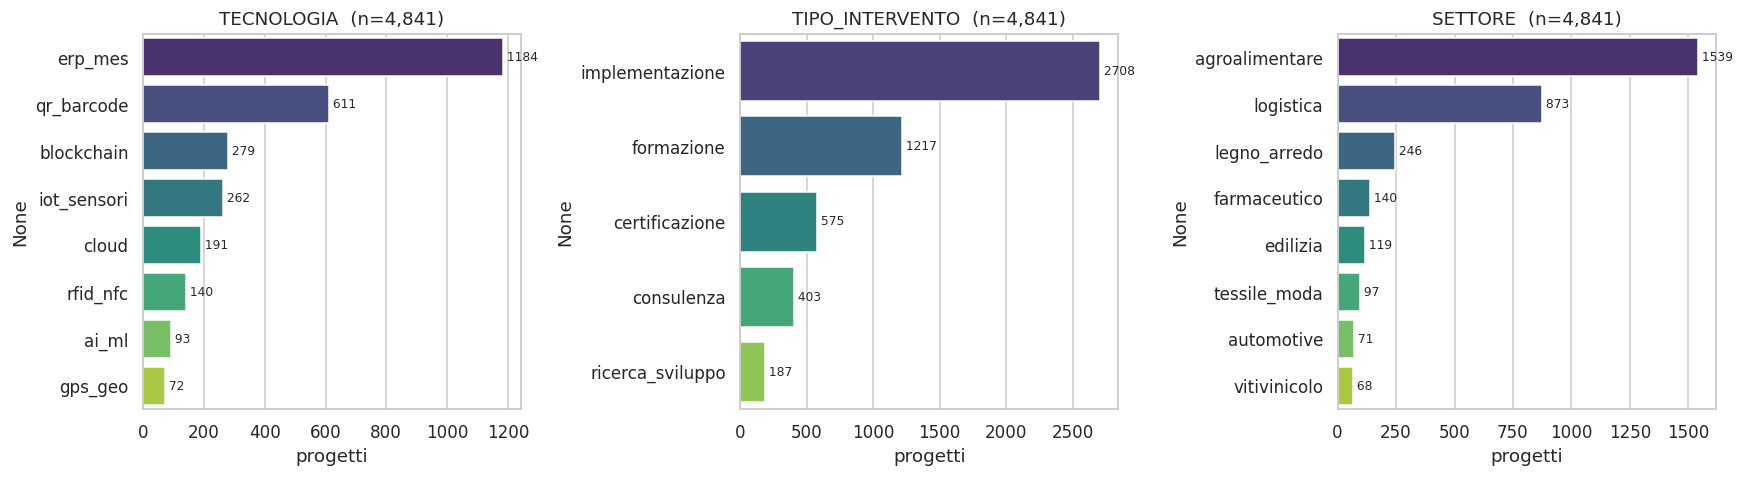


=== TECNOLOGIA ===
             progetti     %
erp_mes          1184  24.5
qr_barcode        611  12.6
blockchain        279   5.8
iot_sensori       262   5.4
cloud             191   3.9
rfid_nfc          140   2.9
ai_ml              93   1.9
gps_geo            72   1.5

=== TIPO_INTERVENTO ===
                  progetti     %
implementazione       2708  55.9
formazione            1217  25.1
certificazione         575  11.9
consulenza             403   8.3
ricerca_sviluppo       187   3.9

=== SETTORE ===
                progetti     %
agroalimentare      1539  31.8
logistica            873  18.0
legno_arredo         246   5.1
farmaceutico         140   2.9
edilizia             119   2.5
tessile_moda          97   2.0
automotive            71   1.5
vitivinicolo          68   1.4

Progetti senza alcuna tecnologia riconosciuta: 56.1% (descrizioni generiche o tecnologia non dichiarata)


In [3]:
tagged = tag_taxonomies(df)

def axis_counts(axis, cats):
    s = pw.onehot(tagged, axis).sum().astype(int)
    return s.sort_values(ascending=False)

counts = {a: axis_counts(a, c) for a, c in
          [('TECNOLOGIA', TECNOLOGIA), ('TIPO_INTERVENTO', TIPO_INTERVENTO), ('SETTORE', SETTORE)]}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (axis, s) in zip(axes, counts.items()):
    sns.barplot(x=s.values, y=s.index, ax=ax, palette='viridis', hue=s.index, legend=False)
    ax.set_title(f'{axis}  (n={len(tagged):,})')
    ax.set_xlabel('progetti')
    for i, v in enumerate(s.values):
        ax.text(v, i, f' {v}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'tassonomie.png'), bbox_inches='tight')
plt.show()

for axis, s in counts.items():
    pct = (s / len(tagged) * 100).round(1)
    print(f"\n=== {axis} ===")
    print(pd.DataFrame({'progetti': s, '%': pct}).to_string())

no_tech = (tagged['TECNOLOGIA__n'] == 0).mean()
print(f"\nProgetti senza alcuna tecnologia riconosciuta: {no_tech:.1%} "
      "(descrizioni generiche o tecnologia non dichiarata)")

### Incrocio tecnologia × tipo di intervento

Risponde direttamente alla domanda: *quanti fanno **blockchain** e quanti fanno
**formazione sulla tracciabilità**?*

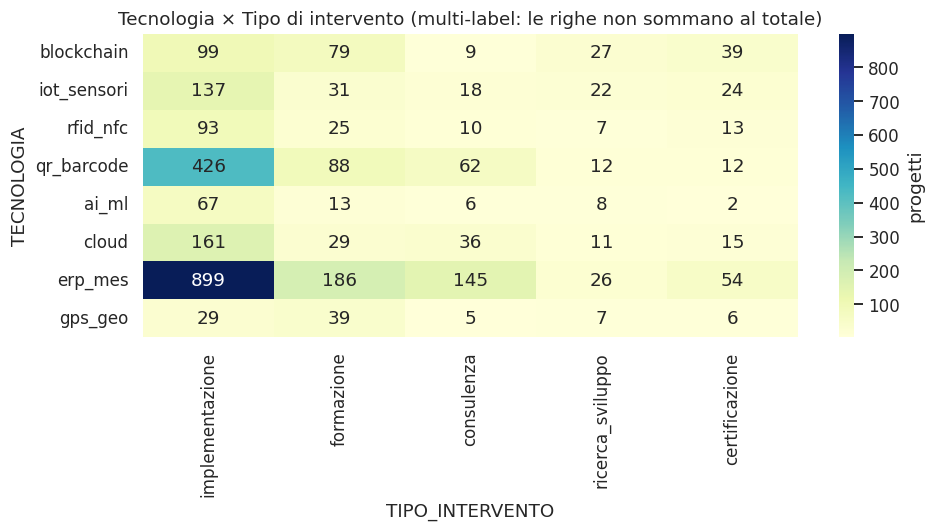

,implementazione,formazione,consulenza,ricerca_sviluppo,certificazione
blockchain,99,79,9,27,39
iot_sensori,137,31,18,22,24
rfid_nfc,93,25,10,7,13
qr_barcode,426,88,62,12,12
ai_ml,67,13,6,8,2
cloud,161,29,36,11,15
erp_mes,899,186,145,26,54
gps_geo,29,39,5,7,6


In [4]:
oh_tec = pw.onehot(tagged, 'TECNOLOGIA')
oh_int = pw.onehot(tagged, 'TIPO_INTERVENTO')
cross = pd.DataFrame(
    {ti: {te: int((oh_tec[te] & oh_int[ti]).sum())
          for te in TECNOLOGIA}
     for ti in TIPO_INTERVENTO}
)

plt.figure(figsize=(9, 5))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'progetti'})
plt.title('Tecnologia × Tipo di intervento (multi-label: le righe non sommano al totale)')
plt.ylabel('TECNOLOGIA'); plt.xlabel('TIPO_INTERVENTO')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'heatmap_tecnologia_intervento.png'), bbox_inches='tight')
plt.show()
cross

### Evoluzione temporale delle tecnologie (2014 → 2025)

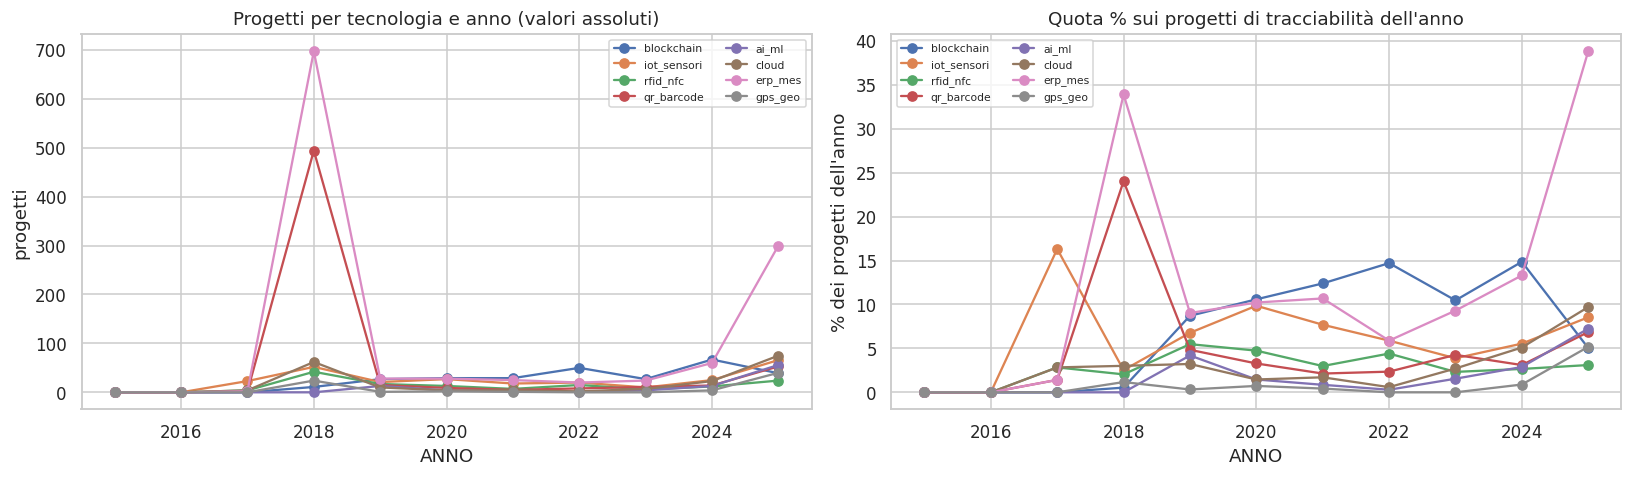

,blockchain,iot_sensori,rfid_nfc,qr_barcode,ai_ml,cloud,erp_mes,gps_geo
ANNO,,,,,,,,
2015,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0
2017,0,23,4,2,0,4,2,0
2018,11,52,42,494,0,62,697,24
2019,27,21,17,15,13,10,28,1
2020,29,27,13,9,4,4,28,2
2021,29,18,7,5,2,4,25,1
2022,50,20,15,8,1,2,20,0
2023,27,10,6,11,4,7,24,0


In [5]:
if 'ANNO' in tagged.columns:
    per_year = pw.onehot(tagged, 'TECNOLOGIA').groupby(tagged['ANNO']).sum()
    tot_year = tagged.groupby('ANNO').size()

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    per_year.plot(marker='o', ax=axes[0])
    axes[0].set_title('Progetti per tecnologia e anno (valori assoluti)')
    axes[0].set_ylabel('progetti'); axes[0].legend(fontsize=7, ncol=2)

    share = per_year.div(tot_year, axis=0) * 100
    share.plot(marker='o', ax=axes[1])
    axes[1].set_title('Quota % sui progetti di tracciabilità dell\'anno')
    axes[1].set_ylabel('% dei progetti dell\'anno'); axes[1].legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'tecnologie_nel_tempo.png'), bbox_inches='tight')
    plt.show()
    display(per_year)

## 3. Analisi lessicale (spaCy `it_core_news_lg`)

Lemmatizzazione con `nlp.pipe(n_process=10)`, tenendo solo NOUN/PROPN/ADJ/VERB.
Oltre alle stopword italiane si rimuove una **stoplist di dominio** (`progetto`, `azienda`,
`obiettivo`, `prevede`, …): sono onnipresenti nel bureaucratese dei bandi e non discriminano nulla.

In [6]:
# deduplico sulla descrizione: lo stesso testo ripetuto su N record gonfierebbe le frequenze
uniq = df.dropna(subset=['DESCRIZIONE_PROGETTO']).drop_duplicates(subset=['DESCRIZIONE_PROGETTO'])
texts = (uniq['TITOLO_PROGETTO'].fillna('').astype(str) + '. '
         + uniq['DESCRIZIONE_PROGETTO'].astype(str)).tolist()
print(f"Documenti unici da lemmatizzare: {len(texts):,}  (n_process={N_PROC})")

%time docs = lemmatize_corpus(texts, n_process=N_PROC)
print(f"Lemmi totali: {sum(len(d) for d in docs):,}")

Documenti unici da lemmatizzare: 3,488  (n_process=10)


CPU times: user 6.48 s, sys: 5.43 s, total: 11.9 s
Wall time: 31.1 s
Lemmi totali: 201,826


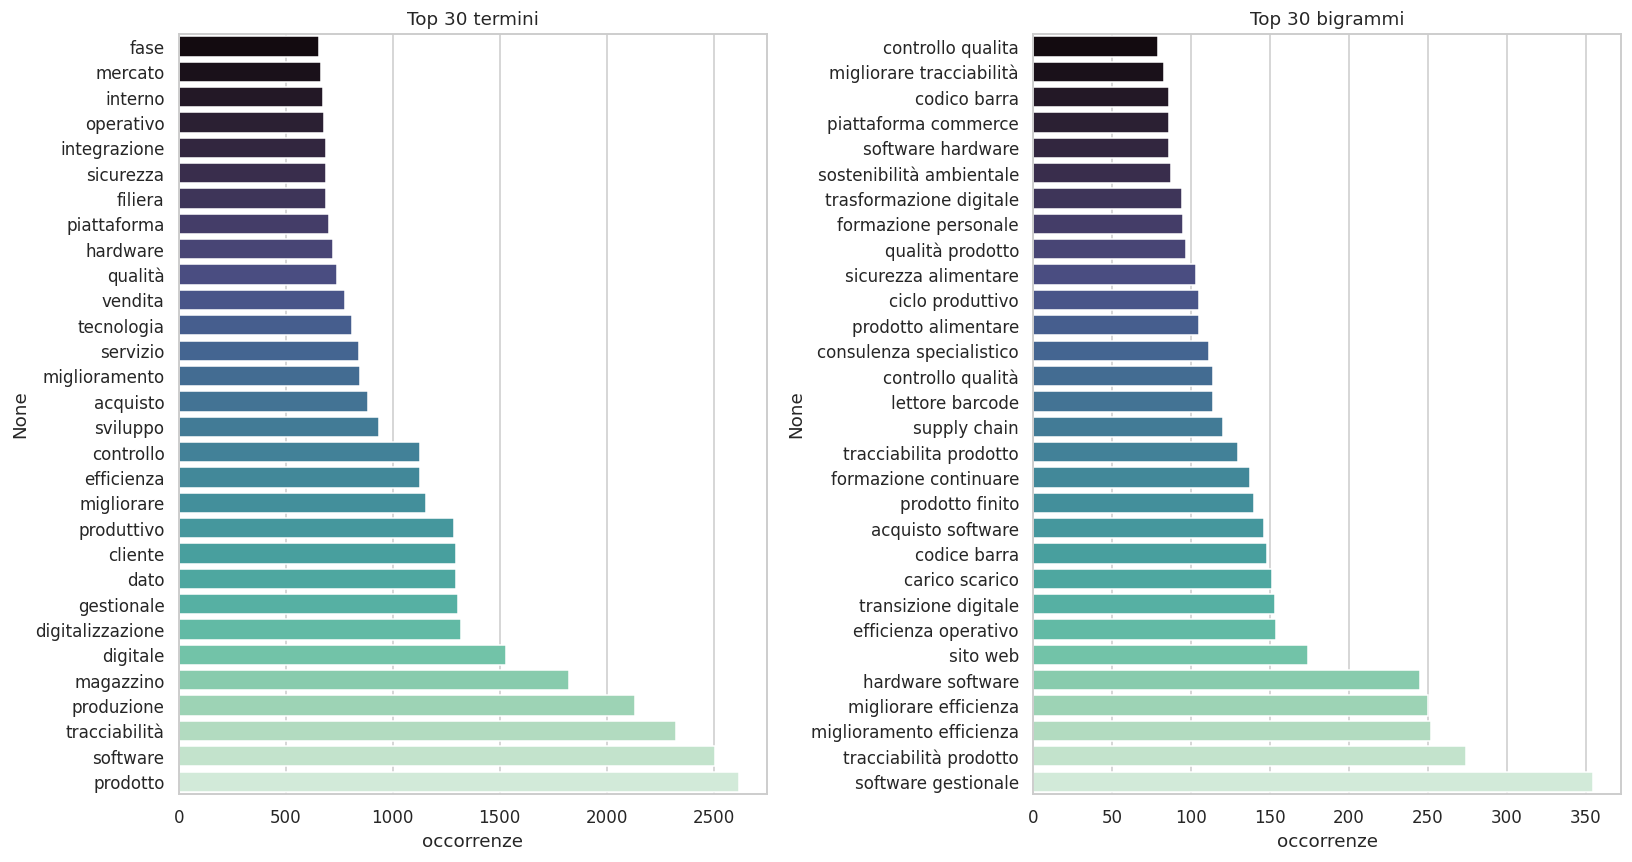

Top 20 bigrammi:
    355  software gestionale
    274  tracciabilità prodotto
    252  miglioramento efficienza
    250  migliorare efficienza
    245  hardware software
    174  sito web
    154  efficienza operativo
    153  transizione digitale
    151  carico scarico
    148  codice barra
    146  acquisto software
    140  prodotto finito
    137  formazione continuare
    130  tracciabilita prodotto
    120  supply chain
    114  controllo qualità
    114  lettore barcode
    111  consulenza specialistico
    105  ciclo produttivo
    105  prodotto alimentare


In [7]:
uni = count_terms(docs, ngram=1)
bi = count_terms(docs, ngram=2)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, (c, title) in zip(axes, [(uni, 'Top 30 termini'), (bi, 'Top 30 bigrammi')]):
    top = pd.Series(dict(c.most_common(30))).sort_values()
    sns.barplot(x=top.values, y=top.index, ax=ax, palette='mako', hue=top.index, legend=False)
    ax.set_title(title); ax.set_xlabel('occorrenze')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'top_termini.png'), bbox_inches='tight')
plt.show()

print("Top 20 bigrammi:")
for term, n in bi.most_common(20):
    print(f"  {n:>5}  {term}")

### Wordcloud complessiva

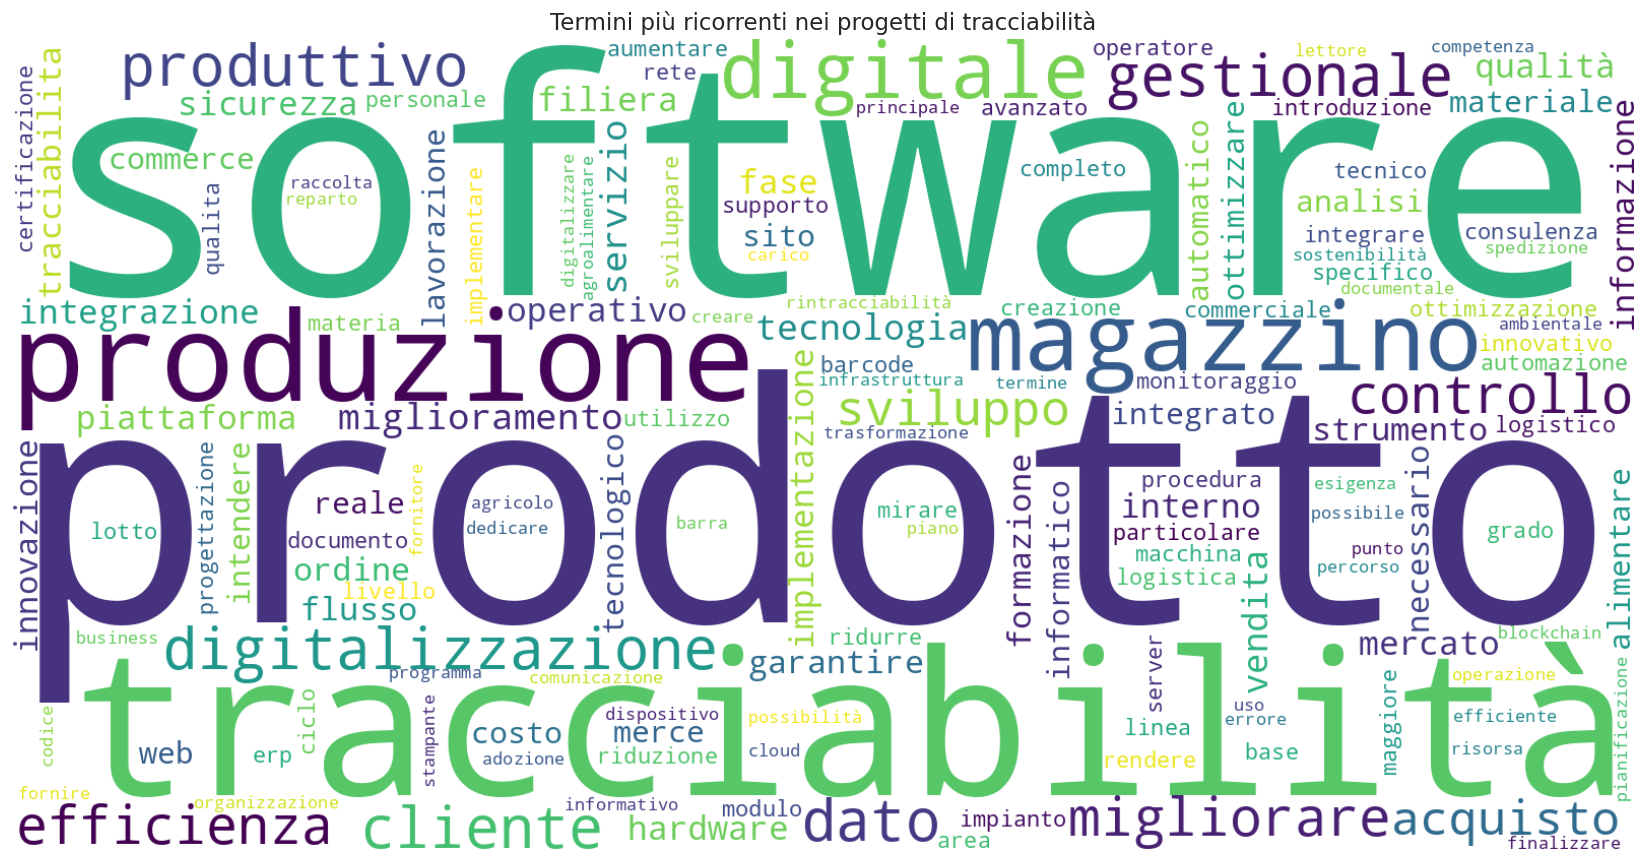

In [8]:
wc = WordCloud(width=1600, height=800, background_color='white',
               colormap='viridis', max_words=150, collocations=False)
wc.generate_from_frequencies(uni)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Termini più ricorrenti nei progetti di tracciabilità', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'wordcloud_generale.png'), bbox_inches='tight', dpi=150)
plt.show()

### Wordcloud per settore

Mostra come cambia il lessico della tracciabilità a seconda della filiera.

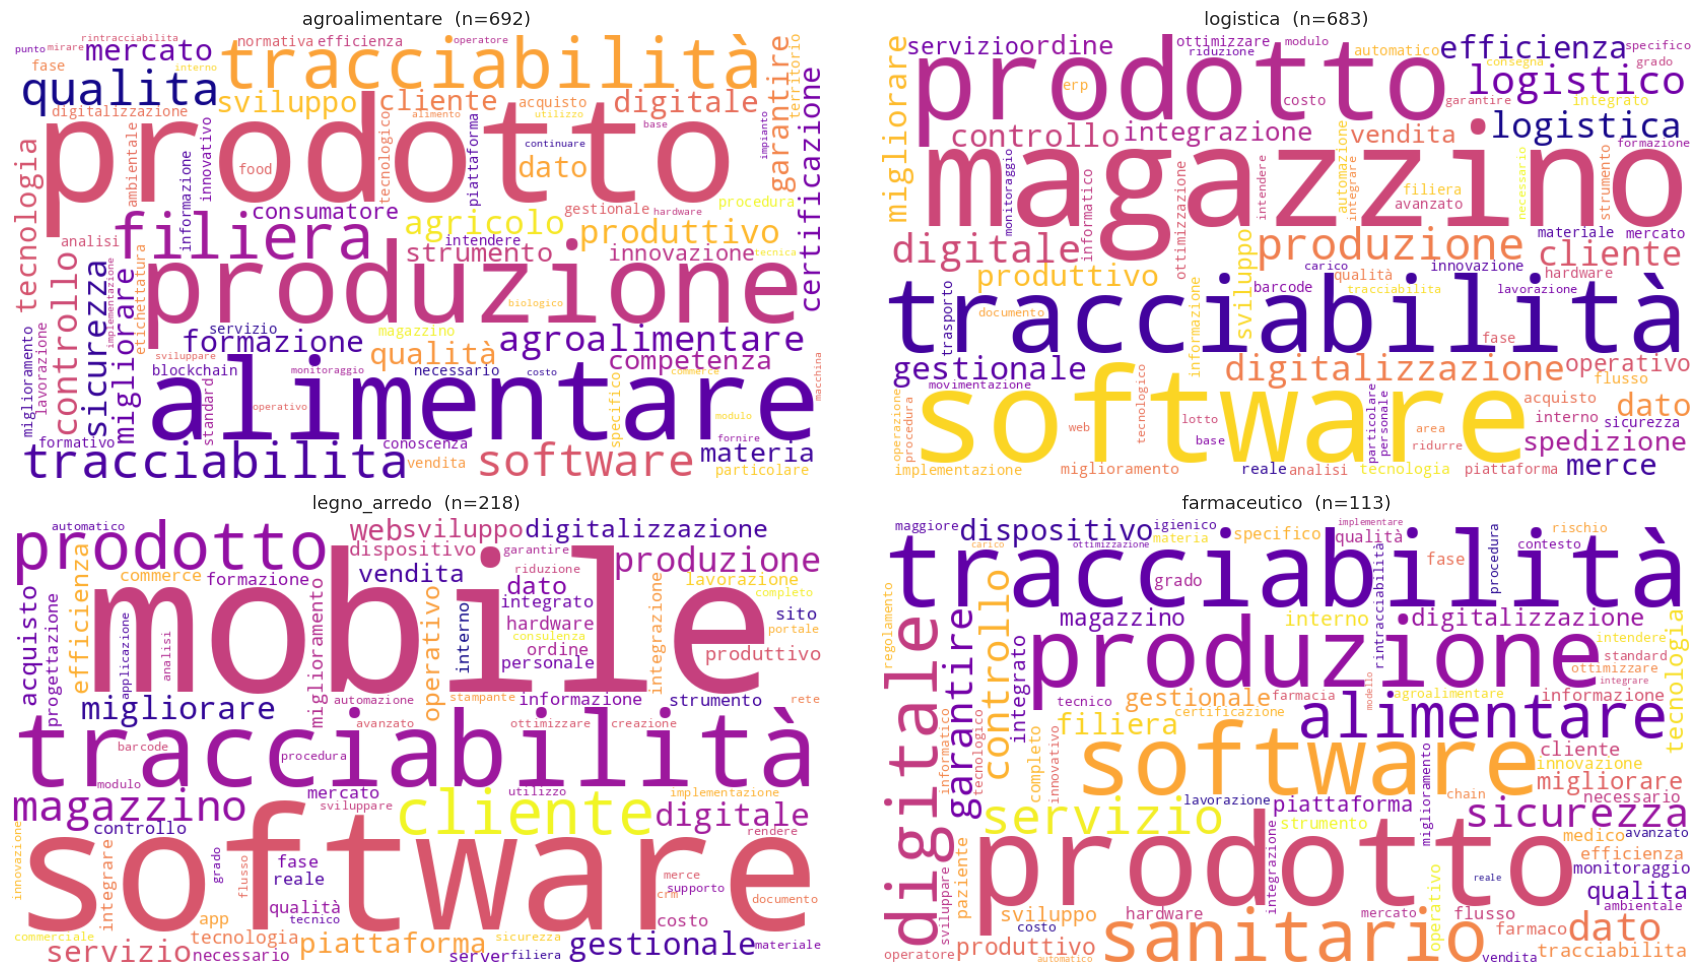

In [9]:
tagged_uniq = tag_taxonomies(uniq).reset_index(drop=True)
oh_set = pw.onehot(tagged_uniq, 'SETTORE')

# i 4 settori più rappresentati
top_sett = [s for s in counts['SETTORE'].index
            if int(oh_set[s].sum()) >= 30][:4]

if top_sett:
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))
    for ax, sett in zip(axes.ravel(), top_sett):
        idx = tagged_uniq.index[oh_set[sett]].tolist()
        freqs = count_terms([docs[i] for i in idx], ngram=1)
        if not freqs:
            ax.axis('off'); continue
        w = WordCloud(width=800, height=440, background_color='white',
                      colormap='plasma', max_words=80, collocations=False)
        w.generate_from_frequencies(freqs)
        ax.imshow(w, interpolation='bilinear'); ax.axis('off')
        ax.set_title(f'{sett}  (n={len(idx)})', fontsize=12)
    for ax in axes.ravel()[len(top_sett):]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'wordcloud_per_settore.png'), bbox_inches='tight', dpi=140)
    plt.show()
else:
    print('Nessun settore con almeno 30 progetti.')

## 4. Esporta il dataset profilato

In [10]:
out = os.path.join(DATA_DIR, 'traceability_profiled.csv')
tagged.to_csv(out, index=False)
print(f"Scritto {out}  ({len(tagged):,} record)")
print(f"Figure salvate in {FIG_DIR}/")
tagged[['ANNO', 'TITOLO_PROGETTO', 'TECNOLOGIA', 'TIPO_INTERVENTO', 'SETTORE']].head(10)

Scritto ../../data/traceability/traceability_profiled.csv  (4,841 record)
Figure salvate in ../../data/traceability/figures/


,ANNO,TITOLO_PROGETTO,TECNOLOGIA,TIPO_INTERVENTO,SETTORE
0,2015,Tracciabilita - Sicurezza,,,
1,2015,Team4Cosemtics - Tracciabilita e sicurezza nel...,,,
2,2015,Mo.Ma.Tra. Movimento Materie Tracciabilita,,,
3,2016,dal campo alla tavola,,,
4,2017,Progetto per il nuovo sistema di produzione e ...,,implementazione,
5,2017,METALINOX 4.0,,,
6,2017,Avanzato sistema adattativo intelligente e pr...,,implementazione,
7,2017,Agri-Sense & Cloud,iot_sensori;cloud,implementazione,agroalimentare
8,2017,Sistemi di gestione qualità e tracciabilità: g...,,,agroalimentare
9,2017,Interventi a favore dell’innovazione nel setto...,,implementazione,legno_arredo
